In [33]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="pyspark")
# Step 2: Create a Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[2]") \
    .appName("MyApp") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.ui.enabled", "false") \
    .getOrCreate()

In [34]:
# Step 3: Now read your CSV
df = spark.read.csv("country_populations.csv", header=True, inferSchema=True)
df.show()
print("Row count:", df.count())

+---+------------+------------+----+--------+
|_c0|Country Name|Country Code|Year|   Value|
+---+------------+------------+----+--------+
|  0| Afghanistan|         AFG|1960| 8996973|
|  1| Afghanistan|         AFG|1961| 9169410|
|  2| Afghanistan|         AFG|1962| 9351441|
|  3| Afghanistan|         AFG|1963| 9543205|
|  4| Afghanistan|         AFG|1964| 9744781|
|  5| Afghanistan|         AFG|1965| 9956320|
|  6| Afghanistan|         AFG|1966|10174836|
|  7| Afghanistan|         AFG|1967|10399926|
|  8| Afghanistan|         AFG|1968|10637063|
|  9| Afghanistan|         AFG|1969|10893776|
| 10|     Albania|         ALB|1960| 1608800|
| 11|     Albania|         ALB|1961| 1659800|
| 12|     Albania|         ALB|1962| 1711319|
| 13|     Albania|         ALB|1963| 1762621|
| 14|     Albania|         ALB|1964| 1814135|
| 15|     Albania|         ALB|1965| 1864791|
| 16|     Albania|         ALB|1966| 1914573|
| 17|     Albania|         ALB|1967| 1965598|
| 18|     Albania|         ALB|196

In [35]:
#converting pyspark dataframe to pandas dataframe
import pandas as pd
pandas_df_from_spark = df.toPandas()
display(pandas_df_from_spark.head())

,_c0,Country Name,Country Code,Year,Value
0,0,Afghanistan,AFG,1960,8996973
1,1,Afghanistan,AFG,1961,9169410
2,2,Afghanistan,AFG,1962,9351441
3,3,Afghanistan,AFG,1963,9543205
4,4,Afghanistan,AFG,1964,9744781


In [36]:
#checking the shape of the pandas dataframe
pandas_df_from_spark.shape

(50, 5)

In [37]:
#checking the schema of the pyspark dataframe
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- Country Name: string (nullable = true)
 |-- Country Code: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Value: integer (nullable = true)



In [38]:
#checking the number of rows in the pyspark dataframe
df.count()

50

In [39]:
#checking the columns of the pyspark dataframe
df.columns

['_c0', 'Country Name', 'Country Code', 'Year', 'Value']

In [40]:
#checking the summary statistics of the pyspark dataframe
df.describe().show()

+-------+------------------+------------+------------+------------------+------------------+
|summary|               _c0|Country Name|Country Code|              Year|             Value|
+-------+------------------+------------+------------+------------------+------------------+
|  count|                50|          50|          50|                50|                50|
|   mean|              24.5|        NULL|        NULL|            1964.5|     1.036962456E7|
| stddev|14.577379737113251|        NULL|        NULL|2.9014422873699495|6949894.8080476085|
|    min|                 0| Afghanistan|         AFG|              1960|           1608800|
|    max|                49|   Argentina|         DZA|              1969|          23494918|
+-------+------------------+------------+------------+------------------+------------------+



In [41]:
#displaying the first 5 rows of the pyspark dataframe
df.show()

+---+------------+------------+----+--------+
|_c0|Country Name|Country Code|Year|   Value|
+---+------------+------------+----+--------+
|  0| Afghanistan|         AFG|1960| 8996973|
|  1| Afghanistan|         AFG|1961| 9169410|
|  2| Afghanistan|         AFG|1962| 9351441|
|  3| Afghanistan|         AFG|1963| 9543205|
|  4| Afghanistan|         AFG|1964| 9744781|
|  5| Afghanistan|         AFG|1965| 9956320|
|  6| Afghanistan|         AFG|1966|10174836|
|  7| Afghanistan|         AFG|1967|10399926|
|  8| Afghanistan|         AFG|1968|10637063|
|  9| Afghanistan|         AFG|1969|10893776|
| 10|     Albania|         ALB|1960| 1608800|
| 11|     Albania|         ALB|1961| 1659800|
| 12|     Albania|         ALB|1962| 1711319|
| 13|     Albania|         ALB|1963| 1762621|
| 14|     Albania|         ALB|1964| 1814135|
| 15|     Albania|         ALB|1965| 1864791|
| 16|     Albania|         ALB|1966| 1914573|
| 17|     Albania|         ALB|1967| 1965598|
| 18|     Albania|         ALB|196

In [42]:
#checking the schema of the pyspark dataframe
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- Country Name: string (nullable = true)
 |-- Country Code: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Value: integer (nullable = true)



In [44]:
from pyspark.sql.functions import col, count, when

# Count null values in each column
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()


+---+------------+------------+----+-----+
|_c0|Country Name|Country Code|Year|Value|
+---+------------+------------+----+-----+
|  0|           0|           0|   0|    0|
+---+------------+------------+----+-----+



In [45]:
# Selecting a specific column from the DataFrame
df.select("Value").show()

+--------+
|   Value|
+--------+
| 8996973|
| 9169410|
| 9351441|
| 9543205|
| 9744781|
| 9956320|
|10174836|
|10399926|
|10637063|
|10893776|
| 1608800|
| 1659800|
| 1711319|
| 1762621|
| 1814135|
| 1864791|
| 1914573|
| 1965598|
| 2022272|
| 2081695|
+--------+
only showing top 20 rows


In [46]:
df.columns

['_c0', 'Country Name', 'Country Code', 'Year', 'Value']

In [52]:
# Selecting multiple columns from the DataFrame
df.select("Country Name", "Country Code").show()

+------------+------------+
|Country Name|Country Code|
+------------+------------+
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
+------------+------------+
only showing top 20 rows


In [54]:
# Filtering rows based on a condition
df.filter(df._c0 == 2712).show()



+---+------------+------------+----+-----+
|_c0|Country Name|Country Code|Year|Value|
+---+------------+------------+----+-----+
+---+------------+------------+----+-----+



In [55]:
df.filter("`Country Name` == 'Afghanistan' AND `Year` == 1960").show()

+---+------------+------------+----+-------+
|_c0|Country Name|Country Code|Year|  Value|
+---+------------+------------+----+-------+
|  0| Afghanistan|         AFG|1960|8996973|
+---+------------+------------+----+-------+



In [56]:
# Filtering rows based on a condition
df.filter(df._c0 == 2712).show()

+---+------------+------------+----+-----+
|_c0|Country Name|Country Code|Year|Value|
+---+------------+------------+----+-----+
+---+------------+------------+----+-----+



In [57]:
df.filter("`Country Name` == 'Afghanistan' OR `Year` == 1964").show()


+---+------------+------------+----+--------+
|_c0|Country Name|Country Code|Year|   Value|
+---+------------+------------+----+--------+
|  0| Afghanistan|         AFG|1960| 8996973|
|  1| Afghanistan|         AFG|1961| 9169410|
|  2| Afghanistan|         AFG|1962| 9351441|
|  3| Afghanistan|         AFG|1963| 9543205|
|  4| Afghanistan|         AFG|1964| 9744781|
|  5| Afghanistan|         AFG|1965| 9956320|
|  6| Afghanistan|         AFG|1966|10174836|
|  7| Afghanistan|         AFG|1967|10399926|
|  8| Afghanistan|         AFG|1968|10637063|
|  9| Afghanistan|         AFG|1969|10893776|
| 14|     Albania|         ALB|1964| 1814135|
| 24|     Algeria|         DZA|1964|12221675|
| 34|      Angola|         AGO|1964| 5673199|
| 44|   Argentina|         ARG|1964|21824520|
+---+------------+------------+----+--------+



In [58]:
df.filter("`Country Name` == 'Afghanistan' AND `Year` == 1977").show()

+---+------------+------------+----+-----+
|_c0|Country Name|Country Code|Year|Value|
+---+------------+------------+----+-----+
+---+------------+------------+----+-----+



In [59]:
df.filter("Year == 1977").show()

+---+------------+------------+----+-----+
|_c0|Country Name|Country Code|Year|Value|
+---+------------+------------+----+-----+
+---+------------+------------+----+-----+



In [60]:
df.groupby("Year").mean("Value").show()

+----+------------+
|Year|  avg(Value)|
+----+------------+
|1961|   9684830.2|
|1968|1.10681738E7|
|1966|1.06542032E7|
|1967|1.08579118E7|
|1969|1.12884322E7|
|1963|1.00614736E7|
|1965|1.04536308E7|
|1960|   9500522.0|
|1964| 1.0255662E7|
|1962|   9871406.0|
+----+------------+



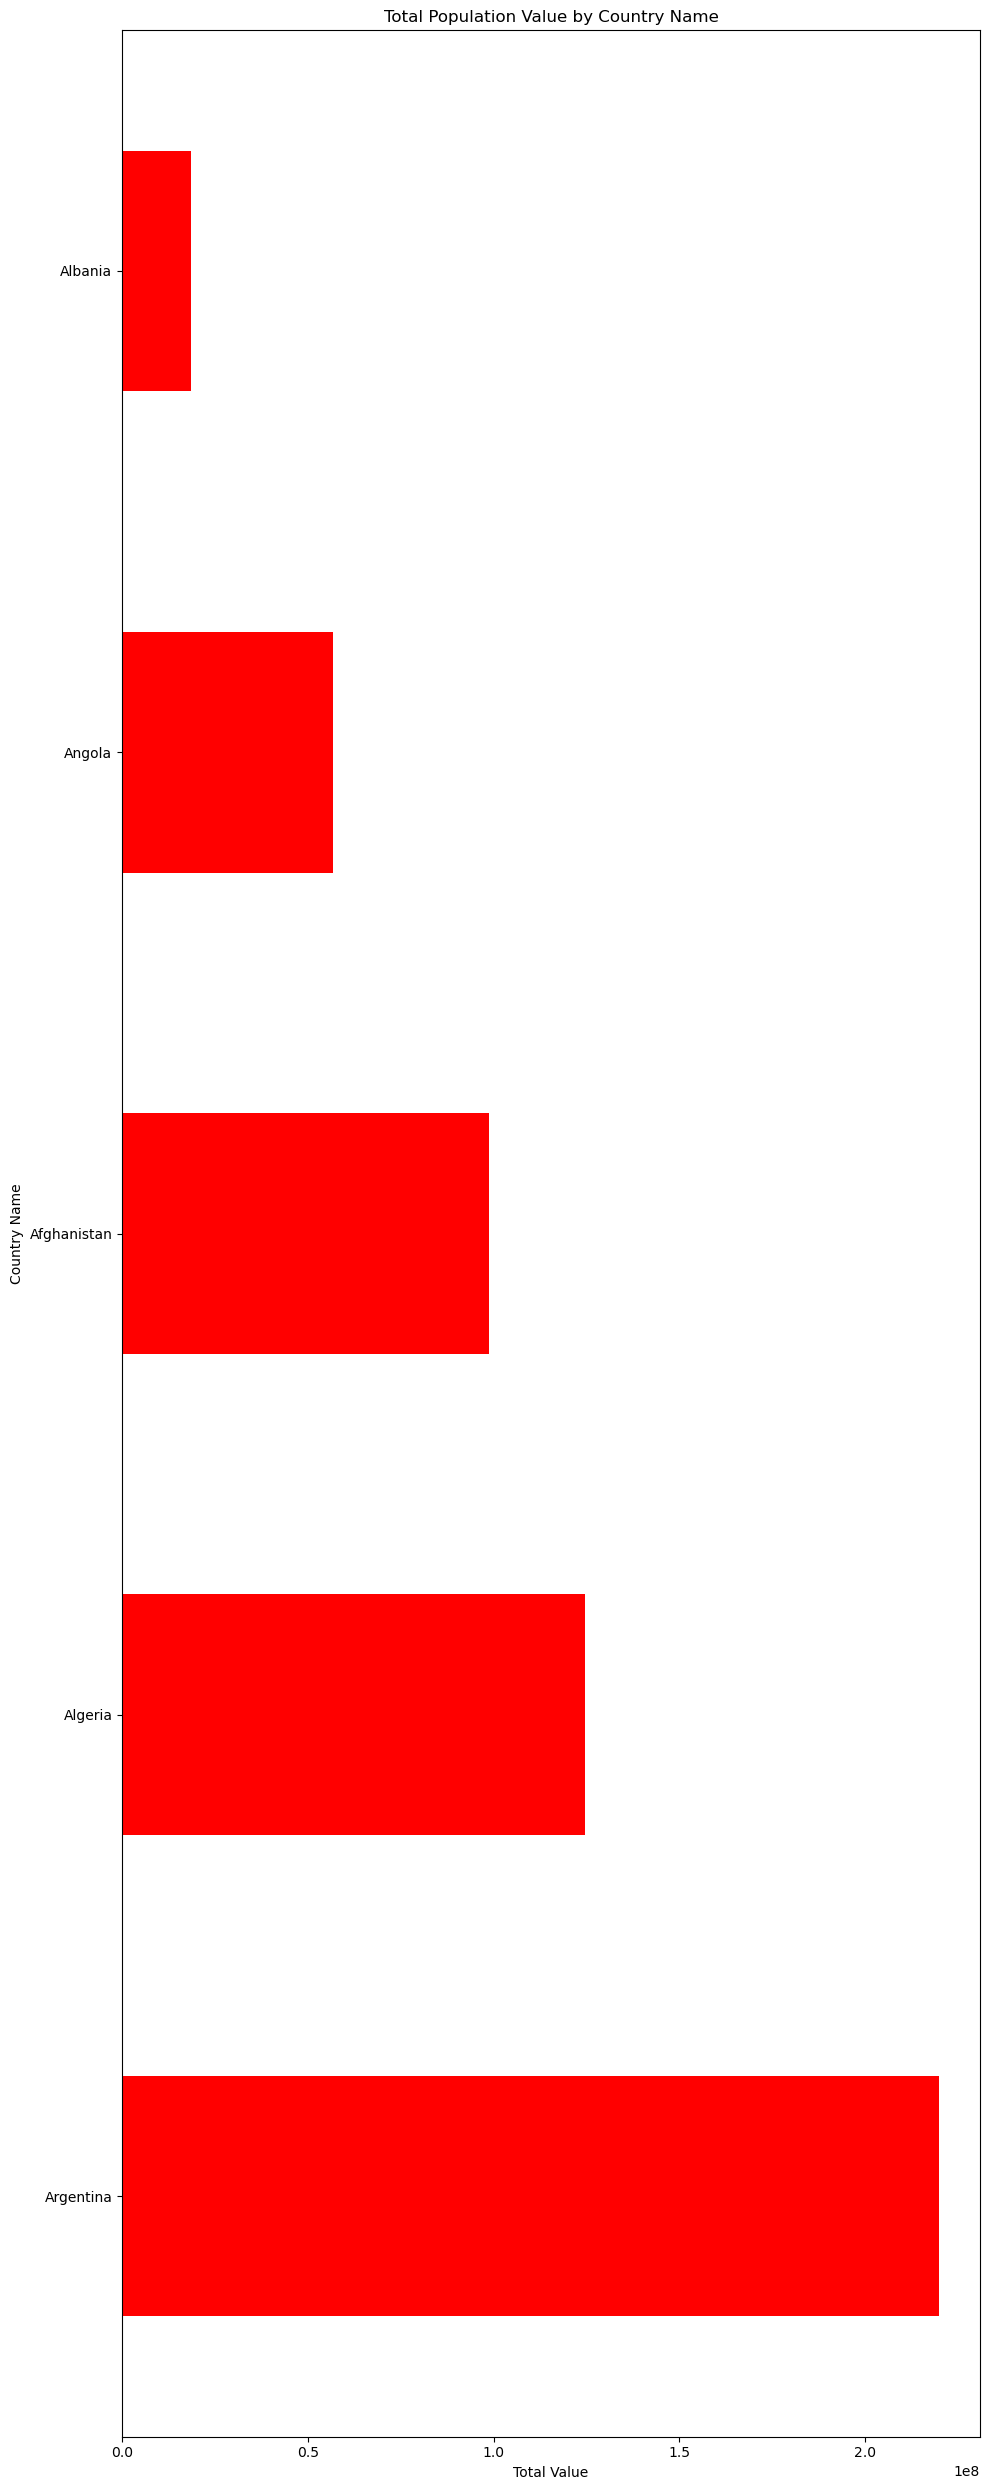

In [80]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pandas_df = df.toPandas()

# Group by 'Country Name' and sum the 'Value' column
grouped_data = pandas_df.groupby("Country Name")["Value"].sum()

# Sort data for better visualization in horizontal bar chart (optional but recommended)
grouped_data = grouped_data.sort_values(ascending=False)

# Plot the grouped data as a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 25)) # Increased figure height for many countries
grouped_data.plot(kind='barh', ax=ax,color='red') # Changed to 'barh' for horizontal bars

plt.title('Total Population Value by Country Name')
plt.xlabel('Total Value') # X-axis is now total value
plt.ylabel('Country Name') # Y-axis is now country name
# For horizontal bar charts, y-axis labels (country names) are usually readable without rotation.
# plt.xticks(rotation=90) # No rotation needed for y-axis labels in barh
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [63]:
#create temporary sql query view
df.createOrReplaceTempView("population_data")


In [64]:
spark.sql("SELECT * FROM population_data").show()

+---+------------+------------+----+--------+
|_c0|Country Name|Country Code|Year|   Value|
+---+------------+------------+----+--------+
|  0| Afghanistan|         AFG|1960| 8996973|
|  1| Afghanistan|         AFG|1961| 9169410|
|  2| Afghanistan|         AFG|1962| 9351441|
|  3| Afghanistan|         AFG|1963| 9543205|
|  4| Afghanistan|         AFG|1964| 9744781|
|  5| Afghanistan|         AFG|1965| 9956320|
|  6| Afghanistan|         AFG|1966|10174836|
|  7| Afghanistan|         AFG|1967|10399926|
|  8| Afghanistan|         AFG|1968|10637063|
|  9| Afghanistan|         AFG|1969|10893776|
| 10|     Albania|         ALB|1960| 1608800|
| 11|     Albania|         ALB|1961| 1659800|
| 12|     Albania|         ALB|1962| 1711319|
| 13|     Albania|         ALB|1963| 1762621|
| 14|     Albania|         ALB|1964| 1814135|
| 15|     Albania|         ALB|1965| 1864791|
| 16|     Albania|         ALB|1966| 1914573|
| 17|     Albania|         ALB|1967| 1965598|
| 18|     Albania|         ALB|196

In [65]:
pd.DataFrame(spark.sql("""
SELECT `Year`,`Country Name` FROM population_data
""").take(3))

,0,1
0,1960,Afghanistan
1,1961,Afghanistan
2,1962,Afghanistan


In [66]:
pd.DataFrame(spark.sql("""
SELECT `Year`,`Country Name` FROM population_data
""").collect())

,0,1
0,1960,Afghanistan
1,1961,Afghanistan
2,1962,Afghanistan
3,1963,Afghanistan
4,1964,Afghanistan
5,1965,Afghanistan
6,1966,Afghanistan
7,1967,Afghanistan
8,1968,Afghanistan
9,1969,Afghanistan


In [68]:
spark.sql("""
SELECT * FROM population_data  WHERE `Country Name` == 'Afghanistan' AND Year == 1964
""").show()

+---+------------+------------+----+-------+
|_c0|Country Name|Country Code|Year|  Value|
+---+------------+------------+----+-------+
|  4| Afghanistan|         AFG|1964|9744781|
+---+------------+------------+----+-------+



In [69]:
spark.sql("""
SELECT * FROM population_data ORDER BY _c0 ASC LIMIT 10
""").show()

+---+------------+------------+----+--------+
|_c0|Country Name|Country Code|Year|   Value|
+---+------------+------------+----+--------+
|  0| Afghanistan|         AFG|1960| 8996973|
|  1| Afghanistan|         AFG|1961| 9169410|
|  2| Afghanistan|         AFG|1962| 9351441|
|  3| Afghanistan|         AFG|1963| 9543205|
|  4| Afghanistan|         AFG|1964| 9744781|
|  5| Afghanistan|         AFG|1965| 9956320|
|  6| Afghanistan|         AFG|1966|10174836|
|  7| Afghanistan|         AFG|1967|10399926|
|  8| Afghanistan|         AFG|1968|10637063|
|  9| Afghanistan|         AFG|1969|10893776|
+---+------------+------------+----+--------+



In [75]:
spark.sql("""
SELECT `Country Name`, `Country Code`
FROM population_data
""").show()

+------------+------------+
|Country Name|Country Code|
+------------+------------+
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
| Afghanistan|         AFG|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
|     Albania|         ALB|
+------------+------------+
only showing top 20 rows


In [78]:
spark.sql("""
SELECT
`Country Name`,
`Country Code`,
Year FROM population_data
""").show()

+------------+------------+----+
|Country Name|Country Code|Year|
+------------+------------+----+
| Afghanistan|         AFG|1960|
| Afghanistan|         AFG|1961|
| Afghanistan|         AFG|1962|
| Afghanistan|         AFG|1963|
| Afghanistan|         AFG|1964|
| Afghanistan|         AFG|1965|
| Afghanistan|         AFG|1966|
| Afghanistan|         AFG|1967|
| Afghanistan|         AFG|1968|
| Afghanistan|         AFG|1969|
|     Albania|         ALB|1960|
|     Albania|         ALB|1961|
|     Albania|         ALB|1962|
|     Albania|         ALB|1963|
|     Albania|         ALB|1964|
|     Albania|         ALB|1965|
|     Albania|         ALB|1966|
|     Albania|         ALB|1967|
|     Albania|         ALB|1968|
|     Albania|         ALB|1969|
+------------+------------+----+
only showing top 20 rows
